# Расчётно-графическая работа №3
**Регрессионные модели и их интерпретация**\
Вариант A-8\

1) построить диаграмму рассеяния и сформулировать гипотезу о характере связи;
2) построить линейную и квадратичную модели;
3) построить дополнительную модель вида y = a x^b;
4) сравнить модели по R², RMSE, средней ошибке аппроксимации и графикам;
5) для линейной модели найти остатки, RSS, оценку дисперсии ошибки и доверительные интервалы для коэффициентов;
6) выполнить прогноз при x*, равном 106% от среднего уровня фактора.

In [22]:
from utils.Reader import Reader
import matplotlib.pyplot as plt
import numpy as np
from prettytable import PrettyTable
from scipy.stats import t

In [23]:
file = Reader("./RGR3_A_8.csv")

X = np.array(file.read_column(1, sep=","))
Y = np.array(file.read_column(2, sep=","))

n = len(X)

## Построение диаграммы рассеяния 

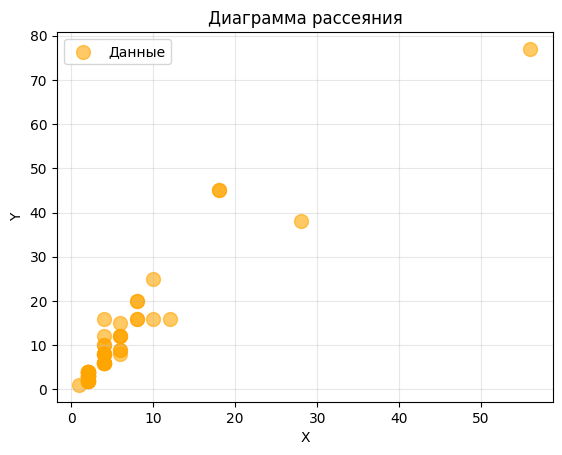

In [24]:
plt.scatter(X, Y, alpha=0.6, s=100, label='Данные', color='orange')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Диаграмма рассеяния")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Данные больше всего похожи на прямую линейную зависимость

# Построение регрессионных моделей

# Оценивание коэффициентов регрессии

## Линейная модель

Рассматривается модель:
$$
\hat{y} = a + bx
$$

Метод наименьших квадратов:
$$
Q(a,b)=\sum_{i=1}^{n}(y_i-a-bx_i)^2
$$

Условия минимума:
$$
\frac{\partial Q}{\partial a}=0,
\quad
\frac{\partial Q}{\partial b}=0
$$

### Производная по \(a\)
$$
\frac{\partial Q}{\partial a}
=
-2\sum (y_i-a-bx_i)=0
$$

$$
\sum y_i - na - b\sum x_i = 0
$$

$$
\overline{y} = a + b\overline{x}
$$

### Производная по \(b\)
$$
\frac{\partial Q}{\partial b}
=
-2\sum x_i(y_i-a-bx_i)=0
$$

$$
\sum x_i y_i - a\sum x_i - b\sum x_i^2 = 0
$$

Подставляя \(a=\overline{y}-b\overline{x}\):
$$
\sum x_i y_i - \overline{y}\sum x_i + b\overline{x}\sum x_i - b\sum x_i^2 = 0
$$

$$
\sum x_i y_i - n\overline{x}\,\overline{y}
=
b(\sum x_i^2 - n\overline{x}^2)
$$

### Итог:
$$
b=\frac{S_{xy}}{S_{xx}}, 
\quad
a=\overline{y}-b\overline{x}
$$

In [25]:
x_mean = np.mean(X)
y_mean = np.mean(Y)

S_xx = np.sum((X - x_mean) ** 2)

S_xy = np.sum(
    (X - x_mean) *
    (Y - y_mean)
)

b_lin = S_xy / S_xx

a_lin = y_mean - b_lin * x_mean

print(f"a = {a_lin}")
print(f"b = {b_lin}")
print(f"y = {a_lin:.4f} + ({b_lin:.4f})x")

a = 1.7626498335062681
b = 1.5080381524622404
y = 1.7626 + (1.5080)x


### Расчёт прогнозных значений и остатков

Прогнозные значения:
$$
\hat{y}_i =
a + bx_i
$$
Остатки:
$$
e_i =
y_i - \hat{y}_i
$$

In [26]:
Y_hat_lin = a_lin + b_lin * X

errors_lin = Y - Y_hat_lin

errors_sq_lin = errors_lin ** 2

table_lin = PrettyTable()

table_lin.field_names = [
    "i",
    "X",
    "Y",
    "Y_hat",
    "e",
    "e^2"
]

for i in range(n):
    table_lin.add_row([
        i + 1,
        round(X[i], 4),
        round(Y[i], 4),
        round(Y_hat_lin[i], 4),
        round(errors_lin[i], 4),
        round(errors_sq_lin[i], 4)
    ])

print(table_lin)

+----+------+------+---------+---------+----------+
| i  |  X   |  Y   |  Y_hat  |    e    |   e^2    |
+----+------+------+---------+---------+----------+
| 1  | 1.0  | 1.0  |  3.2707 | -2.2707 |  5.156   |
| 2  | 2.0  | 4.0  |  4.7787 | -0.7787 |  0.6064  |
| 3  | 2.0  | 4.0  |  4.7787 | -0.7787 |  0.6064  |
| 4  | 2.0  | 3.0  |  4.7787 | -1.7787 |  3.1639  |
| 5  | 2.0  | 4.0  |  4.7787 | -0.7787 |  0.6064  |
| 6  | 2.0  | 2.0  |  4.7787 | -2.7787 |  7.7213  |
| 7  | 2.0  | 2.0  |  4.7787 | -2.7787 |  7.7213  |
| 8  | 2.0  | 2.0  |  4.7787 | -2.7787 |  7.7213  |
| 9  | 2.0  | 3.0  |  4.7787 | -1.7787 |  3.1639  |
| 10 | 2.0  | 2.0  |  4.7787 | -2.7787 |  7.7213  |
| 11 | 2.0  | 2.0  |  4.7787 | -2.7787 |  7.7213  |
| 12 | 2.0  | 3.0  |  4.7787 | -1.7787 |  3.1639  |
| 13 | 2.0  | 4.0  |  4.7787 | -0.7787 |  0.6064  |
| 14 | 2.0  | 2.0  |  4.7787 | -2.7787 |  7.7213  |
| 15 | 2.0  | 3.0  |  4.7787 | -1.7787 |  3.1639  |
| 16 | 2.0  | 4.0  |  4.7787 | -0.7787 |  0.6064  |
| 17 | 2.0  

### Оценка качества линейной модели
Остаточная сумма квадратов:
$$
RSS =
\sum_{i=1}^{n} e_i^2
$$
Общая сумма квадратов:
$$
TSS =
\sum_{i=1}^{n}
(y_i - \overline{y})^2
$$
Коэффициент детерминации:
$$
R^2 =
1 - \frac{RSS}{TSS}
$$
Среднеквадратичная ошибка:
$$
RMSE =
\sqrt{\frac{RSS}{n}}
$$
Средняя ошибка аппроксимации:
$$
A =
\frac{100\%}{n}
\sum_{i=1}^{n}
\left|
\frac{y_i - \hat{y}_i}{y_i}
\right|
$$

In [27]:
RSS_lin = np.sum(errors_sq_lin)

TSS = np.sum((Y - y_mean) ** 2)

R2_lin = 1 - RSS_lin / TSS

RMSE_lin = np.sqrt(RSS_lin / n)

A_lin = (
    100 / n
) * np.sum(
    np.abs(errors_lin / Y)
)

s2_lin = RSS_lin / (n - 2)

s_lin = np.sqrt(s2_lin)

print(f"RSS = {RSS_lin}")
print(f"s^2 = {s2_lin}")
print(f"s = {s_lin}")
print(f"R^2 = {R2_lin}")
print(f"RMSE = {RMSE_lin}")
print(f"A = {A_lin}%")


RSS = 1050.7977893452692
s^2 = 18.117203264573607
s = 4.256430812849377
R^2 = 0.8925711093226619
RMSE = 4.184889065326322
A = 43.40779034768477%


### Доверительные интервалы коэффициентов
Стандартные ошибки коэффициентов:
$$
s_b =
\sqrt{
\frac{s^2}{S_{xx}}
}
$$
$$
s_a =
s \sqrt{
\left(
\frac{1}{n}
+
\frac{\overline{x}^2}{S_{xx}}
\right)
}
$$
Доверительные интервалы:
$$
a \pm t_{кр}s_a
$$
$$
b \pm t_{кр}s_b
$$

In [28]:
alpha = 0.05

t_crit = t.ppf(
    1 - alpha / 2,
    df=n - 2
)

s_b = np.sqrt(s2_lin / S_xx)

s_a = np.sqrt(
    s2_lin * (
        1 / n +
        x_mean**2 / S_xx
    )
)

a_left = a_lin - t_crit * s_a
a_right = a_lin + t_crit * s_a

b_left = b_lin - t_crit * s_b
b_right = b_lin + t_crit * s_b

print("Доверительный интервал для a:")
print(f"({a_left:.4f}; {a_right:.4f})")

print("\nДоверительный интервал для b:")
print(f"({b_left:.4f}; {b_right:.4f})")


Доверительный интервал для a:
(0.4133; 3.1120)

Доверительный интервал для b:
(1.3705; 1.6456)


## Визуализация линейной модели

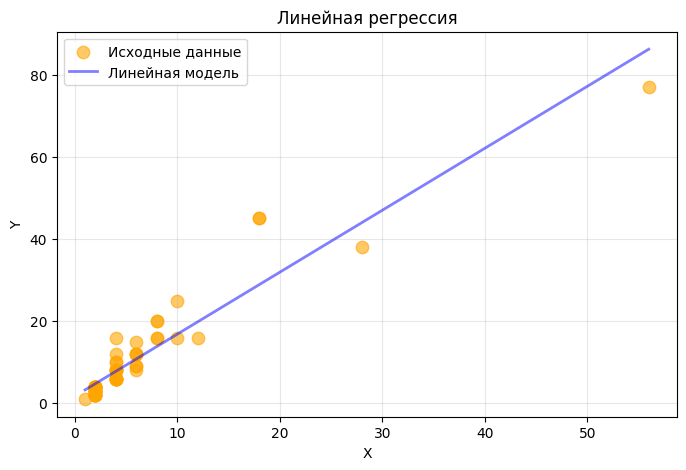

In [29]:
x_plot = np.linspace(np.min(X), np.max(X), 500)

y_plot = a_lin + b_lin * x_plot

plt.figure(figsize=(8, 5))

plt.scatter(
    X,
    Y,
    color='orange',
    s=80,
    label='Исходные данные',
    alpha=0.6,
)

plt.plot(
    x_plot,
    y_plot,
    color='blue',
    linewidth=2,
    alpha=0.5,
    label='Линейная модель'
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Линейная регрессия")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

## Квадратичная модель

Рассматривается модель:
$$
\hat{y} = a + bx + cx^2
$$

Функция ошибок:
$$
Q(a,b,c)=\sum (y_i-a-bx_i-cx_i^2)^2
$$

Условия минимума:
$$
\frac{\partial Q}{\partial a}=0,\quad
\frac{\partial Q}{\partial b}=0,\quad
\frac{\partial Q}{\partial c}=0
$$

---

### Производная по \(a\)
$$
\sum (y_i-a-bx_i-cx_i^2)=0
$$

$$
na + b\sum x_i + c\sum x_i^2 = \sum y_i
$$

---

### Производная по \(b\)
$$
\sum x_i(y_i-a-bx_i-cx_i^2)=0
$$

$$
a\sum x_i + b\sum x_i^2 + c\sum x_i^3 = \sum x_i y_i
$$

---

### Производная по \(c\)
$$
\sum x_i^2(y_i-a-bx_i-cx_i^2)=0
$$

$$
a\sum x_i^2 + b\sum x_i^3 + c\sum x_i^4 = \sum x_i^2 y_i
$$

---

### Система нормальных уравнений:
$$
\begin{cases}
na + b \sum x_i + c \sum x_i^2 = \sum y_i \\
a \sum x_i + b \sum x_i^2 + c \sum x_i^3 = \sum x_i y_i \\
a \sum x_i^2 + b \sum x_i^3 + c \sum x_i^4 = \sum x_i^2 y_i
\end{cases}
$$

In [30]:
sum_x = np.sum(X)
sum_x2 = np.sum(X**2)
sum_x3 = np.sum(X**3)
sum_x4 = np.sum(X**4)
sum_y = np.sum(Y)
sum_xy = np.sum(X * Y)
sum_x2y = np.sum((X**2) * Y)

A = np.array([
    [n,      sum_x,  sum_x2],
    [sum_x,  sum_x2, sum_x3],
    [sum_x2, sum_x3, sum_x4]
])
B = np.array([
    sum_y,
    sum_xy,
    sum_x2y
])
a_quad, b_quad, c_quad = np.linalg.solve(A, B)

print(f"a = {a_quad}")
print(f"b = {b_quad}")
print(f"c = {c_quad}")
print(f"y = {a_quad:.3f} + ({b_quad:.3f})x + ({c_quad:.3f})x^2")

a = -1.3120584509445323
b = 2.342562078053454
c = -0.017325629489277454
y = -1.312 + (2.343)x + (-0.017)x^2


### Прогнозные значения

Для каждого наблюдения вычисляются прогнозы:
$$
\hat{y}_i = a + bx_i + cx_i^2
$$

In [31]:
Y_hat_quad = a_quad + b_quad * X + c_quad * X**2

errors_quad = Y - Y_hat_quad
errors_sq_quad = errors_quad ** 2

table_quad = PrettyTable()

table_quad.field_names = [
    "i",
    "X",
    "Y",
    "Y_hat",
    "e",
    "e^2"
]

for i in range(n):
    table_quad.add_row([
        i + 1,
        round(X[i], 4),
        round(Y[i], 4),
        round(Y_hat_quad[i], 4),
        round(errors_quad[i], 4),
        round(errors_sq_quad[i], 4)
    ])

print(table_quad)

+----+------+------+---------+----------+----------+
| i  |  X   |  Y   |  Y_hat  |    e     |   e^2    |
+----+------+------+---------+----------+----------+
| 1  | 1.0  | 1.0  |  1.0132 | -0.0132  |  0.0002  |
| 2  | 2.0  | 4.0  |  3.3038 |  0.6962  |  0.4847  |
| 3  | 2.0  | 4.0  |  3.3038 |  0.6962  |  0.4847  |
| 4  | 2.0  | 3.0  |  3.3038 | -0.3038  |  0.0923  |
| 5  | 2.0  | 4.0  |  3.3038 |  0.6962  |  0.4847  |
| 6  | 2.0  | 2.0  |  3.3038 | -1.3038  |  1.6998  |
| 7  | 2.0  | 2.0  |  3.3038 | -1.3038  |  1.6998  |
| 8  | 2.0  | 2.0  |  3.3038 | -1.3038  |  1.6998  |
| 9  | 2.0  | 3.0  |  3.3038 | -0.3038  |  0.0923  |
| 10 | 2.0  | 2.0  |  3.3038 | -1.3038  |  1.6998  |
| 11 | 2.0  | 2.0  |  3.3038 | -1.3038  |  1.6998  |
| 12 | 2.0  | 3.0  |  3.3038 | -0.3038  |  0.0923  |
| 13 | 2.0  | 4.0  |  3.3038 |  0.6962  |  0.4847  |
| 14 | 2.0  | 2.0  |  3.3038 | -1.3038  |  1.6998  |
| 15 | 2.0  | 3.0  |  3.3038 | -0.3038  |  0.0923  |
| 16 | 2.0  | 4.0  |  3.3038 |  0.6962  |  0.4

### Оценка качества модели
Остаточная сумма квадратов:
$$
RSS =
\sum_{i=1}^{n} e_i^2
$$
Общая сумма квадратов:
$$
TSS = \sum_{i=1}^{n} (y_i - \overline{y})^2
$$
Коэффициент детерминации:
$$
R^2 = 1 - \frac{RSS}{TSS}
$$
Средняя ошибка аппроксимации:
$$
A =
\frac{100\%}{n}
\sum_{i=1}^{n}
\left|
\frac{y_i - \hat{y}_i}{y_i}
\right|
$$
Среднеквадратичная ошибка:
$$
RMSE =
\sqrt{\frac{RSS}{n}}
$$

In [32]:
RSS_quad = np.sum(errors_sq_quad)

R2_quad = 1 - RSS_quad / TSS

RMSE_quad = np.sqrt(RSS_quad / n)

A_quad = (
    100 / n
) * np.sum(
    np.abs(errors_quad / Y)
)

print(f"RSS = {RSS_quad}")
print(f"R^2 = {R2_quad}")
print(f"RMSE = {RMSE_quad}")
print(f"A = {A_quad}%")

RSS = 670.5072286085223
R^2 = 0.9314503242289542
RMSE = 3.3429209498294608
A = 23.755450235934486%


### Визуализация квадратичной модели

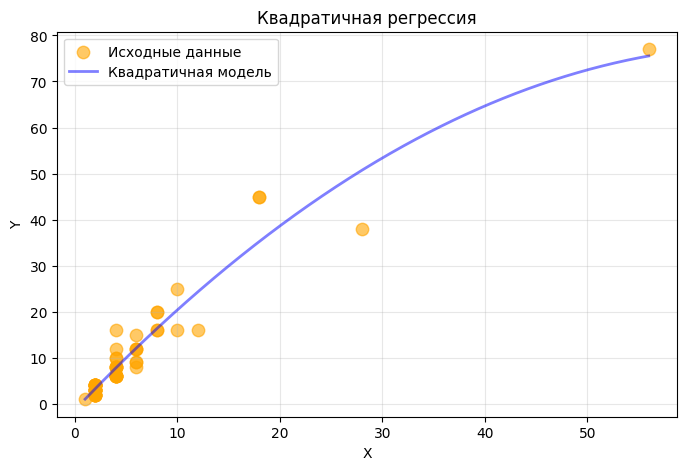

In [33]:
x_plot = np.linspace(np.min(X), np.max(X), 500)

y_plot_quad = a_quad + b_quad * x_plot + c_quad * x_plot**2

plt.figure(figsize=(8, 5))

plt.scatter(
    X,
    Y,
    color='orange',
    s=80,
    label='Исходные данные',
    alpha=0.6,
)

plt.plot(
    x_plot,
    y_plot_quad,
    color='blue',
    linewidth=2,
    alpha=0.5,
    label='Квадратичная модель'
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Квадратичная регрессия")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

## Степенная модель

Рассматривается модель:
$$
y = ax^b
$$

Линеаризация:
$$
\ln y = \ln a + b \ln x
$$

Обозначим:
$$
z=\ln y,\quad t=\ln x,\quad \alpha=\ln a
$$

Получаем:
$$
z=\alpha + bt
$$

Функция ошибок:
$$
Q(\alpha,b)=\sum (z_i-\alpha-bt_i)^2
$$

Условия минимума:
$$
\frac{\partial Q}{\partial \alpha}=0,\quad
\frac{\partial Q}{\partial b}=0
$$

---

### Производная по \( $\alpha$ \)
$$
\sum (z_i-\alpha-bt_i)=0
$$

$$
n\alpha + b\sum t_i = \sum z_i
$$

$$
\alpha = \overline{z} - b\overline{t}
$$

---

### Производная по \(b\)
$$
\sum t_i(z_i-\alpha-bt_i)=0
$$

$$
\sum t_i z_i - \alpha\sum t_i - b\sum t_i^2 = 0
$$

Подставим \( $\alpha$ \):
$$
\sum t_i z_i - \overline{z}\sum t_i + b\overline{t}\sum t_i - b\sum t_i^2 = 0
$$

$$
\sum t_i z_i - n\overline{t}\,\overline{z}
=
b(\sum t_i^2 - n\overline{t}^2)
$$

---

### Итог:
$$
b=\frac{S_{tz}}{S_{tt}}, 
\quad
\alpha=\overline{z}-b\overline{t}, 
\quad
a=e^\alpha
$$

In [34]:
T = np.log(X)
Z = np.log(Y)

t_mean = np.mean(T)
z_mean = np.mean(Z)

Вычислим вспомогательные суммы:
$$
S_{tt} =
\sum_{i=1}^{n}
(t_i - \overline{t})^2
$$
$$
S_{tz} =
\sum_{i=1}^{n}
(t_i - \overline{t})(z_i - \overline{z})
$$
Тогда оценки коэффициентов:
$$
b =
\frac{S_{tz}}{S_{tt}}
$$
$$
\alpha =
\overline{z} - b\overline{t}
$$

In [35]:
S_tt = np.sum((T - t_mean) ** 2)

S_tz = np.sum((T - t_mean) * (Z - z_mean))

b_pow = S_tz / S_tt

alpha_pow = z_mean - b_pow * t_mean

a_pow = np.exp(alpha_pow)

print(f"alpha = {alpha_pow}")
print(f"a = {a_pow}")
print(f"b = {b_pow}")
print(f"y = {a_pow:.3f} * x^({b_pow:.3f})")

alpha = 0.38399362505170176
a = 1.468136082360537
b = 1.1141552634479626
y = 1.468 * x^(1.114)


### Прогнозные значения
Для каждого наблюдения вычисляются прогнозы:
$$
\hat{y}_i = ax_i^b
$$

In [36]:
Y_hat_pow = a_pow * (X ** b_pow)

errors_pow = Y - Y_hat_pow
errors_pow_sq = errors_pow ** 2

table_pow = PrettyTable()

table_pow.field_names = [
    "i",
    "X",
    "Y",
    "Y_hat",
    "e",
    "e^2"
]

for i in range(n):
    table_pow.add_row([
        i + 1,
        round(X[i], 4),
        round(Y[i], 4),
        round(Y_hat_pow[i], 4),
        round(errors_pow[i], 4),
        round(errors_pow_sq[i], 4)
    ])

print(table_pow)

+----+------+------+----------+----------+-----------+
| i  |  X   |  Y   |  Y_hat   |    e     |    e^2    |
+----+------+------+----------+----------+-----------+
| 1  | 1.0  | 1.0  |  1.4681  | -0.4681  |   0.2192  |
| 2  | 2.0  | 4.0  |  3.178   |  0.822   |   0.6756  |
| 3  | 2.0  | 4.0  |  3.178   |  0.822   |   0.6756  |
| 4  | 2.0  | 3.0  |  3.178   |  -0.178  |   0.0317  |
| 5  | 2.0  | 4.0  |  3.178   |  0.822   |   0.6756  |
| 6  | 2.0  | 2.0  |  3.178   |  -1.178  |   1.3878  |
| 7  | 2.0  | 2.0  |  3.178   |  -1.178  |   1.3878  |
| 8  | 2.0  | 2.0  |  3.178   |  -1.178  |   1.3878  |
| 9  | 2.0  | 3.0  |  3.178   |  -0.178  |   0.0317  |
| 10 | 2.0  | 2.0  |  3.178   |  -1.178  |   1.3878  |
| 11 | 2.0  | 2.0  |  3.178   |  -1.178  |   1.3878  |
| 12 | 2.0  | 3.0  |  3.178   |  -0.178  |   0.0317  |
| 13 | 2.0  | 4.0  |  3.178   |  0.822   |   0.6756  |
| 14 | 2.0  | 2.0  |  3.178   |  -1.178  |   1.3878  |
| 15 | 2.0  | 3.0  |  3.178   |  -0.178  |   0.0317  |
| 16 | 2.0

### Оценка качества модели
Остаточная сумма квадратов:
$$
RSS =
\sum_{i=1}^{n} e_i^2
$$
Коэффициент детерминации:
$$
R^2 = 1 - \frac{RSS}{TSS}
$$
Средняя ошибка аппроксимации:
$$
A =
\frac{100\%}{n}
\sum_{i=1}^{n}
\left|
\frac{y_i - \hat{y}_i}{y_i}
\right|
$$
Среднеквадратичная ошибка:
$$
RMSE =
\sqrt{\frac{RSS}{n}}
$$

In [37]:
RSS_pow = np.sum(errors_pow_sq)

R2_pow = 1 - RSS_pow / TSS

A_pow = (100 / n) * np.sum(np.abs(errors_pow / Y))

RMSE_pow = np.sqrt(RSS_pow / n)

print(f"RSS = {RSS_pow}")
print(f"R^2 = {R2_pow}")
print(f"RMSE = {RMSE_pow}")
print(f"A = {A_pow}%")

RSS = 3800.7304399495424
R^2 = 0.6114302303759329
RMSE = 7.958989089858861
A = 24.965159062595585%


### Визуализация степенной модели

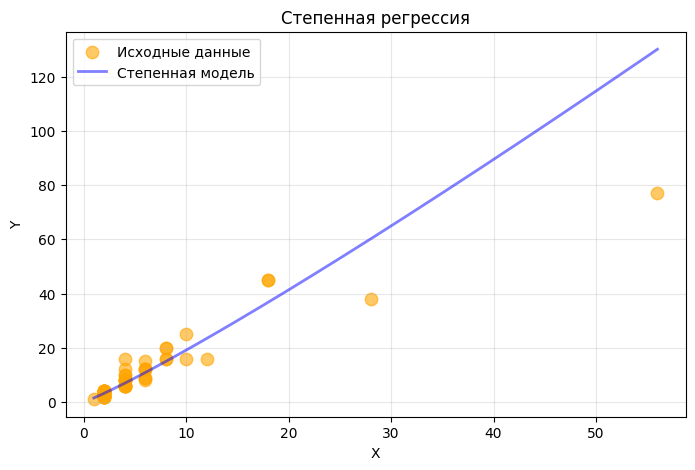

In [38]:
x_plot = np.linspace(np.min(X), np.max(X), 500)

y_plot_pow = a_pow * (x_plot ** b_pow)

plt.figure(figsize=(8, 5))

plt.scatter(
    X,
    Y,
    color='orange',
    s=80,
    alpha=0.6,
    label='Исходные данные'
)

plt.plot(
    x_plot,
    y_plot_pow,
    color='blue',
    linewidth=2,
    alpha=0.5,
    label='Степенная модель'
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Степенная регрессия")
plt.grid(True, alpha=0.3)
plt.legend()


# Сравнение моделей

In [39]:
table_models = PrettyTable()

table_models.field_names = [
    "Модель",
    "RSS",
    "RMSE",
    "R^2",
    "A (%)"
]

table_models.add_row([
    "Линейная",
    round(RSS_lin, 4),
    round(RMSE_lin, 4),
    round(R2_lin, 4),
    round(A_lin, 4)
])

table_models.add_row([
    "Квадратичная",
    round(RSS_quad, 4),
    round(RMSE_quad, 4),
    round(R2_quad, 4),
    round(A_quad, 4)
])

table_models.add_row([
    "Степенная",
    round(RSS_pow, 4),
    round(RMSE_pow, 4),
    round(R2_pow, 4),
    round(A_pow, 4)
])

print(table_models)

+--------------+-----------+--------+--------+---------+
|    Модель    |    RSS    |  RMSE  |  R^2   |  A (%)  |
+--------------+-----------+--------+--------+---------+
|   Линейная   | 1050.7978 | 4.1849 | 0.8926 | 43.4078 |
| Квадратичная |  670.5072 | 3.3429 | 0.9315 | 23.7555 |
|  Степенная   | 3800.7304 | 7.959  | 0.6114 | 24.9652 |
+--------------+-----------+--------+--------+---------+


## Прогноз при x* = 106% от среднего уровня фактора

In [40]:
x_star = 1.06 * np.mean(X)

print(f"x* = {x_star}")

# Линейная модель
y_star_lin = a_lin + b_lin * x_star

# Квадратичная модель
y_star_quad = (
    a_quad +
    b_quad * x_star +
    c_quad * x_star**2
)

# Степенная модель
y_star_pow = a_pow * (x_star ** b_pow)

print("\nПрогнозы моделей:")

print(f"Линейная модель: y* = {y_star_lin:.4f}")

print(f"Квадратичная модель: y* = {y_star_quad:.4f}")

print(f"Степенная модель: y* = {y_star_pow:.4f}")

x* = 6.024333333333334

Прогнозы моделей:
Линейная модель: y* = 10.8476
Квадратичная модель: y* = 12.1715
Степенная модель: y* = 10.8569
